In [1]:
import pandas as pd
import numpy as np


np.random.seed(42)
n = 1200

# generate synthetic base data
r_and_d = np.random.normal(loc=150000, scale=25000, size=n)
administration = np.random.normal(loc=120000, scale=20000, size=n)
marketing_spend = np.random.normal(loc=380000, scale=50000, size=n)
profit = 0.22 * r_and_d + 0.08 * administration + 0.26 * marketing_spend + np.random.normal(loc=0, scale=18000, size=n)

# inject outliers
outlier_idx = np.random.choice(n, size=30, replace=False)
r_and_d[outlier_idx[:10]] *= np.random.uniform(2.5, 4.5, size=10)
administration[outlier_idx[10:20]] *= np.random.uniform(2.5, 4.5, size=10)
marketing_spend[outlier_idx[20:]] *= np.random.uniform(2.5, 4.5, size=10)
profit[outlier_idx] *= np.random.uniform(2.5, 4.5, size=30)

df = pd.DataFrame({
    "r&d_spend": r_and_d,
    "administration": administration,
    "marketing_spend": marketing_spend,
    "profit": profit
})

df.head()

,r&d_spend,administration,marketing_spend,profit
0,162417.853825,122504.490053,343913.122333,120118.860087
1,146543.392471,111411.889177,388841.043607,129307.198689
2,166192.213453,122445.950061,352665.995771,174947.739589
3,188075.746410,130865.960581,366417.244484,147126.715364
4,610358.729252,120977.201407,463672.604515,651880.899759


In [2]:
df3 = df.sample(3)

In [3]:
df3

,r&d_spend,administration,marketing_spend,profit
57,142269.690604,128380.380187,391970.225027,105925.423004
947,132702.298253,103430.059504,459529.103631,155913.444666
928,189138.100731,134307.626309,325391.818364,136000.942610


In [4]:
df

,r&d_spend,administration,marketing_spend,profit
0,162417.853825,122504.490053,343913.122333,120118.860087
1,146543.392471,111411.889177,388841.043607,129307.198689
2,166192.213453,122445.950061,352665.995771,174947.739589
3,188075.746410,130865.960581,366417.244484,147126.715364
4,610358.729252,120977.201407,463672.604515,651880.899759
...,...,...,...,...
1195,161011.868449,91007.095606,437322.043520,133654.798999
1196,149509.055027,101562.803737,331331.058099,135914.417759
1197,163812.248860,99920.852558,430356.666824,120836.404732
1198,155597.853352,124145.346588,396807.248151,110426.605753


In [5]:
df3['f0(x)'] = df3['profit'].mean()

In [6]:
df3

,r&d_spend,administration,marketing_spend,profit,f0(x)
57,142269.690604,128380.380187,391970.225027,105925.423004,132613.270093
947,132702.298253,103430.059504,459529.103631,155913.444666,132613.270093
928,189138.100731,134307.626309,325391.818364,136000.942610,132613.270093


In [7]:
df3['r1'] = df3['profit'] - df3['f0(x)']
df3

,r&d_spend,administration,marketing_spend,profit,f0(x),r1
57,142269.690604,128380.380187,391970.225027,105925.423004,132613.270093,-26687.847089
947,132702.298253,103430.059504,459529.103631,155913.444666,132613.270093,23300.174573
928,189138.100731,134307.626309,325391.818364,136000.942610,132613.270093,3387.672516


In [8]:
from sklearn.tree import DecisionTreeRegressor
dt1 = DecisionTreeRegressor(max_depth=1)
dt1.fit(df3[['r&d_spend', 'administration', 'marketing_spend']], df3['r1'])
df3['f1(x)'] = dt1.predict(df3[['r&d_spend', 'administration', 'marketing_spend']])
df3

,r&d_spend,administration,marketing_spend,profit,f0(x),r1,f1(x)
57,142269.690604,128380.380187,391970.225027,105925.423004,132613.270093,-26687.847089,-11650.087286
947,132702.298253,103430.059504,459529.103631,155913.444666,132613.270093,23300.174573,23300.174573
928,189138.100731,134307.626309,325391.818364,136000.942610,132613.270093,3387.672516,-11650.087286


[Text(0.5, 0.75, 'marketing_spend <= 425749.656\nsquared_error = 422205214.151\nsamples = 3\nvalue = 0.0'),
 Text(0.25, 0.25, 'squared_error = 226134219.886\nsamples = 2\nvalue = -11650.087'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'squared_error = 0.0\nsamples = 1\nvalue = 23300.175'),
 Text(0.625, 0.5, '  False')]

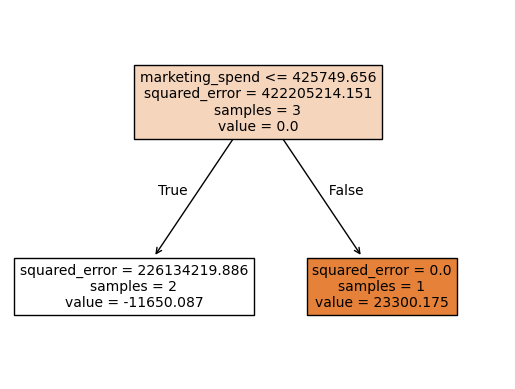

In [9]:
from sklearn.tree import plot_tree
plot_tree(dt1, feature_names=['r&d_spend', 'administration', 'marketing_spend'], filled=True)